In [343]:
import numpy as np
import matplotlib.pyplot as plt

In [344]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
a_min = 0.1 # AU
a_max = 1000 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33
f_g = 1
f_d = 1
eta_ice = 1

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [345]:
## Disk structure helper functions

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def gamma(a):
    """Calculates the gravitational focusing factor."""
    return np.sqrt(alpha) * H(a) / a

## Embryo and planetesimal helper functions

def M_pltsml(R_pltsml):
    """Calculates the mass of a planetesimal assuming constant density in Earth masses."""
    return (4/3) * np.pi * (R_pltsml * 1e5) ** 3 * rho_pltsml / M_earth

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Planetesimal accretion helper functions

def v_esc(M_core):
    """Calculates the escape velocity from the core in cm/s."""
    return np.sqrt(2 * G * M_core * M_earth / (R_core(M_core) * 1e5))

def v_H(M_core, a_core):
    """Calculates the Hill velocity in cm/s."""
    return Omega_K(a_core) * R_H(M_core, a_core) * AU

def v_low(M_core, a_core):
    """Calculates the dynamically thin disk regime threshold in cm/s (Rafikov 2011)."""
    return Omega_K(a_core) * np.sqrt((R_H(M_core, a_core) * AU) * (R_core(M_core) * 1e5))

def p(M_core, a_core):
    """Calculates the ratio of the core radius to the Hill radius."""
    return (R_core(M_core) * 1e5) / (R_H(M_core, a_core) * AU)

def s(sigma, M_core, a_core):
    """Calculates the ratio of the velocity dispersion of the planetesimals to the Hill velocity."""
    return sigma / v_H(M_core, a_core)

In [346]:
## Planetesimal accretion rates (Rafikov 2011) (Dones et al 1993)

def dM_dt(sigma, M_core, a_core):
    """Calculates the planetesimal core accretion rate in M_earth/s. Accretion regimes from Rafikov (2011) and accretion rates from Dones et al (1993)."""

    ## Very high dispersion, weak gravitational focusing
    if sigma > v_esc(M_core):
        return 2.7603 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) ** 2 / M_earth

    ## High dispersion, moderate gravitational focusing
    elif v_H(M_core, a_core) < sigma <= v_esc(M_core):
        return 6.0828 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) * s(sigma, M_core, a_core) ** (-2) / M_earth

    ## Intermediate dispersion, strong gravitational focusing
    elif v_low(M_core, a_core) < sigma <= v_H(M_core, a_core):
        return 10.1 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) * s(sigma, M_core, a_core) ** (-1) / M_earth

    ## Very low dispersion, dynamically thin disk
    else:
        return 6.47 * Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * p(M_core, a_core) ** (1/2) / M_earth

In [347]:
## Equilibrium eccentricities (Kokubo & Ida 2002) (Ida & Makino 1993) (Ida et al 2008)

def e_eq_kokubo(M_core, a, R_pltsml):
    """Calculates the equilibrium eccentricity of planetesimals based on Kokubo & Ida (2002)."""
    e_eq_tilde = 5.6 * (M_pltsml(R_pltsml) * M_earth / 10 ** 23) ** (1/15) * (rho_core / 2) ** (2/15) * (b_tilde * D * rho_mid(a) * a / (10 * (2 * 10 ** -9))) ** (-1/5)
    return e_eq_tilde * (R_H(M_core, a) / a)

def e_eq_makino(M_core, a, R_pltsml):
    """Calculates the equilibrium eccentricity of planetesimals based on Ida & Makino (1993)."""
    e_mm = 20 * (M_pltsml(R_pltsml) * M_earth / 10 ** 23) ** (-1/15) * a ** (9/20) * (2 * M_pltsml(R_pltsml) * M_earth / (3 * M_star * M_sun)) ** (1/3)
    e_Mm = 6 * (M_pltsml(R_pltsml) * M_earth / 10 ** 23) ** (1/18) * (a / 5) ** (7/24) * ((M_core + M_pltsml(R_pltsml)) * M_earth / (3 * M_star * M_sun)) ** (1/3)
    return np.max((e_mm, e_Mm), axis = 0)

def e_eq_ida(M_core, a, R_pltsml):
    """Calculates the equilibrium eccentricity of planetesimals based on Ida et al (2008)."""
    e_tidal = 24 * f_g ** (1/2) * gamma(a) * (R_pltsml / 10 ** 3) ** (-3/2) * (rho_core / 3) ** (-1/2) * a ** (3/4)
    e_drag = 0.23 * f_g ** (1/3) * gamma(a) ** (2/3) * R_pltsml ** (1/3) * (rho_core / 3) ** (1/3) * a ** (11/12)
    e_coll = 3.6 * f_g * (f_d * eta_ice) ** (-1/2) * gamma(a) * R_pltsml ** (1/2) * (rho_core / 3) ** (5/6) * a ** (5/4)
    return np.min((e_tidal, e_drag, e_coll), axis = 0)

## Velocity dispersion

def velocity_dispersion(M_core, a, R_pltsml, model = None):
    """Calculates the velocity dispersion of planetesimals based on the equilibrium eccentricity."""

    if model == 'kokubo':
        e_eq = e_eq_kokubo(M_core, a, R_pltsml)

    elif model == 'makino':
        e_eq = e_eq_makino(M_core, a, R_pltsml)
    
    elif model == 'ida':
        e_eq = e_eq_ida(M_core, a, R_pltsml)
    
    else:
        e_eq = np.max((e_eq_kokubo(M_core, a, R_pltsml), e_eq_makino(M_core, a, R_pltsml), e_eq_ida(M_core, a, R_pltsml)), axis = 0)

    return e_eq * Omega_K(a) * a * AU

## Isolation mass

def M_iso(a_core):
    """Calculates the isolation mass in terms of Earth masses."""
    return (2 * np.pi * (a_core * AU) ** 2 * b_tilde * Sigma_s(a_core)) ** (3/2) * (3 * M_star * M_sun) ** (-1/2) / M_earth

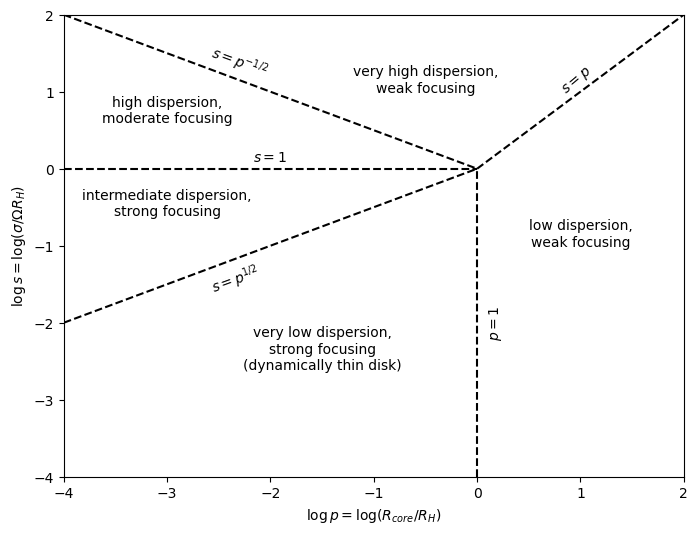

In [348]:
## Accretion regimes plot

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlim(-4, 2)
ax.set_ylim(-4, 2)

# Lines
ax.plot((0, 0), (-4, 0), 'k--')
ax.plot((-4, 0), (0, 0), 'k--')
ax.plot((-4, 0), (2, 0), 'k--')
ax.plot((-4, 0), (-2, 0), 'k--')
ax.plot((0, 2), (0, 2), 'k--')

# Line labels
ax.text(0.1, -2, r'$p = 1$', rotation = 90, va = 'center')
ax.text(-2, 0.1, r'$s = 1$', ha = 'center')
ax.text(-2.6, 1.2, r'$s = p^{-1/2}$', rotation = -20)
ax.text(-2.6, -1.6, r'$s = p^{1/2}$', rotation = 20)
ax.text(0.8, 1.0, r'$s = p$', rotation = 40)

ax.set_xlabel(r'$\log p = \log (R_{core} / R_H)$')
ax.set_ylabel(r'$\log s = \log (\sigma / \Omega R_H)$')

# Region labels
ax.text(-0.5, 1, 'very high dispersion,\nweak focusing', fontsize = 10, ha = 'center')
ax.text(-3, 0.6, 'high dispersion,\nmoderate focusing', fontsize = 10, ha = 'center')
ax.text(-3, -0.6, 'intermediate dispersion,\nstrong focusing', fontsize = 10, ha = 'center')
ax.text(-1.5, -2.6, 'very low dispersion,\nstrong focusing\n(dynamically thin disk)', fontsize = 10, ha = 'center')
ax.text(1, -1, 'low dispersion,\nweak focusing', fontsize = 10, ha = 'center')

plt.show()

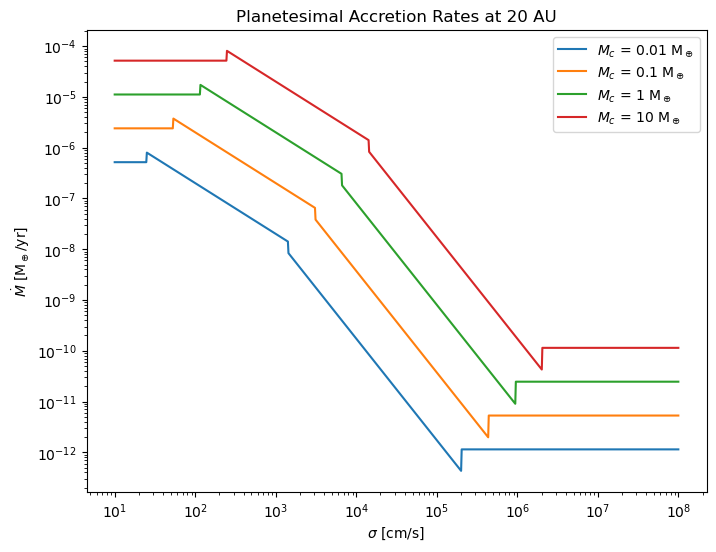

In [349]:
## Plot dM/dt vs sigma

fig, ax = plt.subplots(figsize = (8, 6))

sigmas = np.logspace(1, 8, 1000) # cm/s
M_cores = [0.01, 0.1, 1, 10] # M_earth
a_core = 20 # AU

for M_core in M_cores:
    Mdot_values = [dM_dt(sigma, M_core, a_core) * year for sigma in sigmas]
    ax.plot(sigmas, Mdot_values, label = fr'$M_c$ = {M_core} M$_\oplus$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\sigma$ [cm/s]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a_core} AU')
ax.legend()
plt.show()

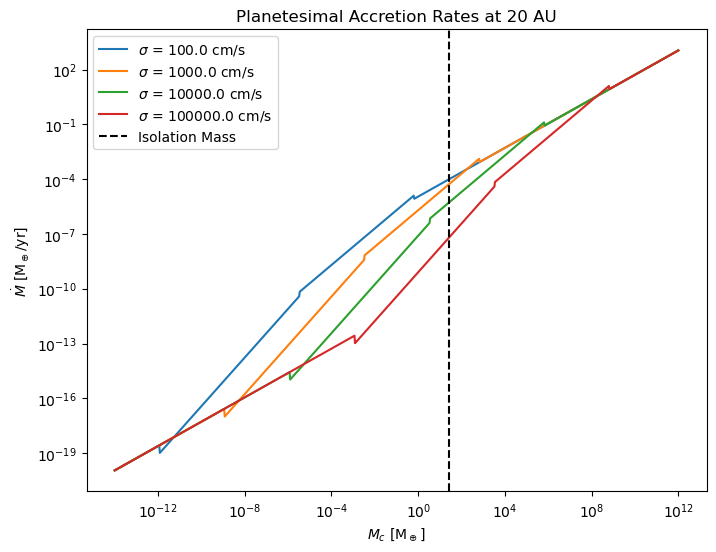

In [350]:
## Plot dM/dt vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

sigmas = [1e2, 1e3, 1e4, 1e5] # cm/s
M_cores = np.logspace(-14, 12, 1000) # M_earth
a_core = 20 # AU

for sigma in sigmas:
    Mdot_values = [dM_dt(sigma, M_core, a_core) * year for M_core in M_cores]
    ax.plot(M_cores, Mdot_values, label = fr'$\sigma$ = {sigma} cm/s')

## Isolation mass
plt.axvline(M_iso(a_core), color = 'black', linestyle = '--', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a_core} AU')
ax.legend(loc = 'upper left')
plt.show()

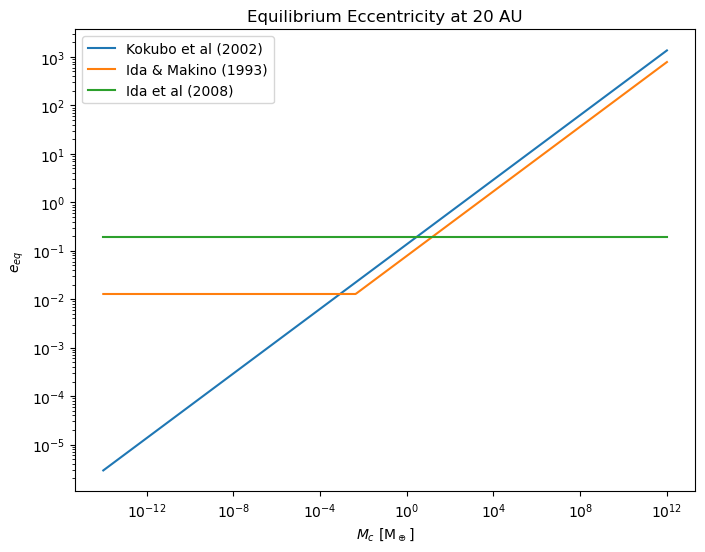

In [351]:
## Plot e_eq vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

M_cores = np.logspace(-14, 12, 1000) # M_earth
a = 20 # AU
R_pltsml = 100 # km

e_eq_kokubo_values = [e_eq_kokubo(M_core, a, R_pltsml) for M_core in M_cores]
e_eq_makino_values = [e_eq_makino(M_core, a, R_pltsml) for M_core in M_cores]
e_eq_ida_values = [e_eq_ida(M_core, a, R_pltsml) for M_core in M_cores]

ax.plot(M_cores, e_eq_kokubo_values, label = 'Kokubo et al (2002)')
ax.plot(M_cores, e_eq_makino_values, label = 'Ida & Makino (1993)')
ax.plot(M_cores, e_eq_ida_values, label = 'Ida et al (2008)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$e_{eq}$')
plt.title(f'Equilibrium Eccentricity at {a} AU')
ax.legend()
plt.show()

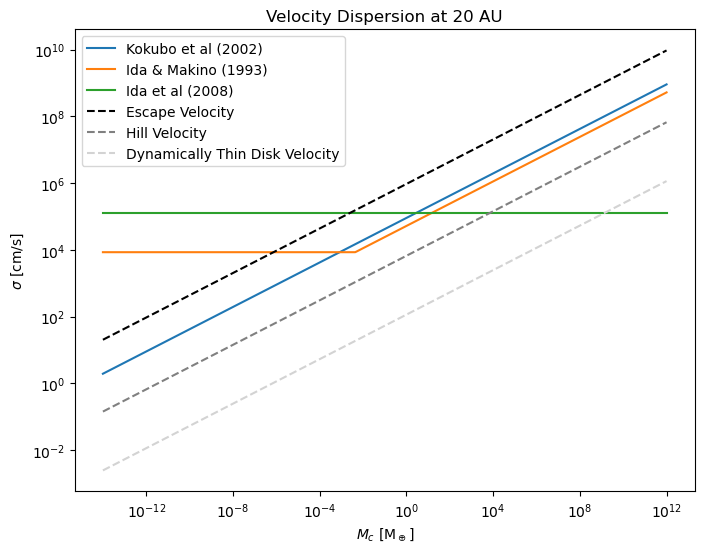

In [352]:
## Plot sigma vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

M_cores = np.logspace(-14, 12, 1000) # M_earth
a = 20 # AU
R_pltsml = 100 # km

sigma_kokubo_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'kokubo') for M_core in M_cores]
sigma_makino_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'makino') for M_core in M_cores]
sigma_ida_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'ida') for M_core in M_cores]
sigma_max_values = [velocity_dispersion(M_core, a, R_pltsml) for M_core in M_cores]

ax.plot(M_cores, sigma_kokubo_values, label = 'Kokubo et al (2002)')
ax.plot(M_cores, sigma_makino_values, label = 'Ida & Makino (1993)')
ax.plot(M_cores, sigma_ida_values, label = 'Ida et al (2008)')

## Accretion rate transitions
ax.plot(M_cores, v_esc(M_cores), color = 'black', linestyle = '--', label = 'Escape Velocity')
ax.plot(M_cores, v_H(M_cores, a), color = 'grey', linestyle = '--', label = 'Hill Velocity')
ax.plot(M_cores, v_low(M_cores, a), color = 'lightgrey', linestyle = '--', label = 'Dynamically Thin Disk Velocity')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\sigma$ [cm/s]')
plt.title(f'Velocity Dispersion at {a} AU')
ax.legend()
plt.show()

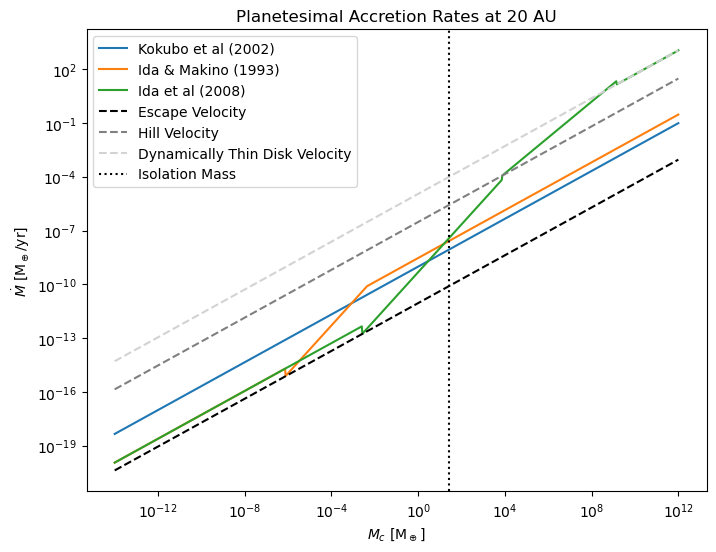

In [353]:
## Plot dM/dt vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

M_cores = np.logspace(-14, 12, 1000) # M_earth
a = 20 # AU
R_pltsml = 100 # km

sigma_kokubo_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'kokubo') for M_core in M_cores]
sigma_makino_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'makino') for M_core in M_cores]
sigma_ida_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'ida') for M_core in M_cores]

Mdot_kokubo_values = [dM_dt(sigma, M_core, a) * year for sigma, M_core in zip(sigma_kokubo_values, M_cores)]
Mdot_makino_values = [dM_dt(sigma, M_core, a) * year for sigma, M_core in zip(sigma_makino_values, M_cores)]
Mdot_ida_values = [dM_dt(sigma, M_core, a) * year for sigma, M_core in zip(sigma_ida_values, M_cores)]

ax.plot(M_cores, Mdot_kokubo_values, label = 'Kokubo et al (2002)')
ax.plot(M_cores, Mdot_makino_values, label = 'Ida & Makino (1993)')
ax.plot(M_cores, Mdot_ida_values, label = 'Ida et al (2008)')

## Accretion rate transitions
ax.plot(M_cores, [dM_dt(v_esc(M_core), M_core, a) * year for M_core in M_cores], color = 'black', linestyle = '--', label = 'Escape Velocity')
ax.plot(M_cores, [dM_dt(v_H(M_core, a), M_core, a) * year for M_core in M_cores], color = 'grey', linestyle = '--', label = 'Hill Velocity')
ax.plot(M_cores, [dM_dt(v_low(M_core, a), M_core, a) * year for M_core in M_cores], color = 'lightgrey', linestyle = '--', label = 'Dynamically Thin Disk Velocity')

## Isolation mass
plt.axvline(M_iso(a), color = 'black', linestyle = ':', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a} AU')
ax.legend(loc = 'upper left')
plt.show()

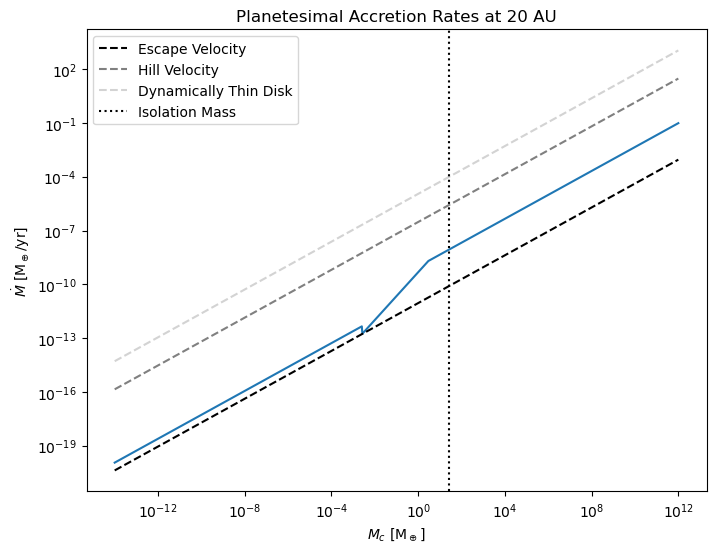

In [354]:
## Plot dM/dt vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

M_cores = np.logspace(-14, 12, 1000) # M_earth
a = 20 # AU
R_pltsml = 100 # km

sigma_values = [velocity_dispersion(M_core, a, R_pltsml) for M_core in M_cores]

Mdot_values = [dM_dt(sigma, M_core, a) * year for sigma, M_core in zip(sigma_values, M_cores)]

ax.plot(M_cores, Mdot_values)

## Accretion rate transitions
ax.plot(M_cores, [dM_dt(v_esc(M_core), M_core, a) * year for M_core in M_cores], color = 'black', linestyle = '--', label = 'Escape Velocity')
ax.plot(M_cores, [dM_dt(v_H(M_core, a), M_core, a) * year for M_core in M_cores], color = 'grey', linestyle = '--', label = 'Hill Velocity')
ax.plot(M_cores, [dM_dt(v_low(M_core, a), M_core, a) * year for M_core in M_cores], color = 'lightgrey', linestyle = '--', label = 'Dynamically Thin Disk')

## Isolation mass
plt.axvline(M_iso(a), color = 'black', linestyle = ':', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a} AU')
ax.legend(loc = 'upper left')
plt.show()

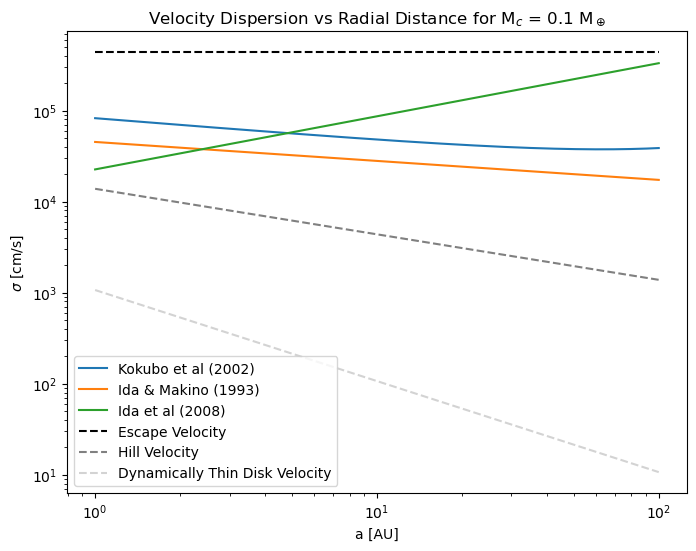

In [355]:
## Plot sigma vs a

fig, ax = plt.subplots(figsize = (8, 6))

M_core = 0.1 # M_earth
R_pltsml = 100 # km
distances = np.logspace(0, 2, 1000) # AU

sigma_kokubo_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'kokubo') for a in distances]
sigma_makino_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'makino') for a in distances]
sigma_ida_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'ida') for a in distances]

ax.plot(distances, sigma_kokubo_values, label = 'Kokubo et al (2002)')
ax.plot(distances, sigma_makino_values, label = 'Ida & Makino (1993)')
ax.plot(distances, sigma_ida_values, label = 'Ida et al (2008)')

## Accretion rate transitions
ax.plot(distances, [v_esc(M_core) for a in distances], color = 'black', linestyle = '--', label = 'Escape Velocity')
ax.plot(distances, [v_H(M_core, a) for a in distances], color = 'grey', linestyle = '--', label = 'Hill Velocity')
ax.plot(distances, [v_low(M_core, a) for a in distances], color = 'lightgrey', linestyle = '--', label = 'Dynamically Thin Disk Velocity')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'a [AU]')
ax.set_ylabel(r'$\sigma$ [cm/s]')
plt.title(fr'Velocity Dispersion vs Radial Distance for M$_c$ = {M_core} M$_\oplus$')
ax.legend()
plt.show()

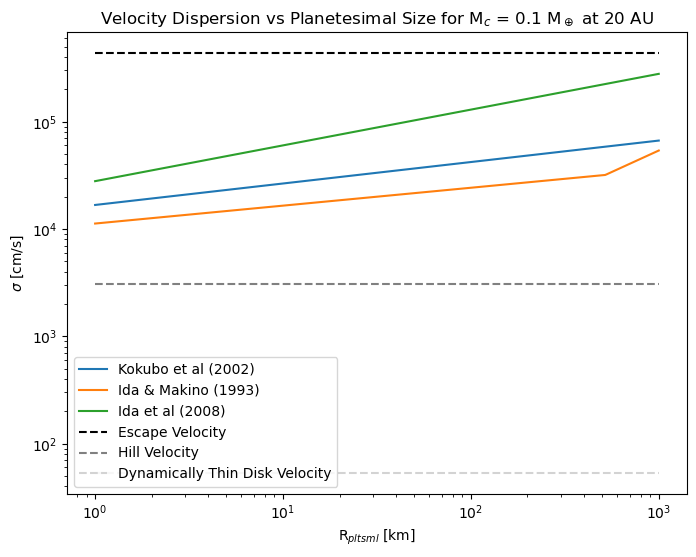

In [356]:
## Plot sigma vs R_pltsml

fig, ax = plt.subplots(figsize = (8, 6))

M_core = 0.1 # M_earth
a = 20 # AU
R_pltsmls = np.logspace(0, 3, 1000) # km

sigma_kokubo_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'kokubo') for R_pltsml in R_pltsmls]
sigma_makino_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'makino') for R_pltsml in R_pltsmls]
sigma_ida_values = [velocity_dispersion(M_core, a, R_pltsml, model = 'ida') for R_pltsml in R_pltsmls]

ax.plot(R_pltsmls, sigma_kokubo_values, label = 'Kokubo et al (2002)')
ax.plot(R_pltsmls, sigma_makino_values, label = 'Ida & Makino (1993)')
ax.plot(R_pltsmls, sigma_ida_values, label = 'Ida et al (2008)')

## Accretion rate transitions
ax.plot(R_pltsmls, [v_esc(M_core) for _ in R_pltsmls], color = 'black', linestyle = '--', label = 'Escape Velocity')
ax.plot(R_pltsmls, [v_H(M_core, a) for _ in R_pltsmls], color = 'grey', linestyle = '--', label = 'Hill Velocity')
ax.plot(R_pltsmls, [v_low(M_core, a) for _ in R_pltsmls], color = 'lightgrey', linestyle = '--', label = 'Dynamically Thin Disk Velocity')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'R$_{pltsml}$ [km]')
ax.set_ylabel(r'$\sigma$ [cm/s]')
plt.title(fr'Velocity Dispersion vs Planetesimal Size for M$_c$ = {M_core} M$_\oplus$ at {a} AU')
ax.legend()
plt.show()